In [ ]:
import pandas as pd
import numpy as np
import os
from synth_pat.paths import Paths
from synth_pat.scripts.plot_utils import plot_med_results

feat = ['L.PU-L.CACG',
'L.PU-L.RACG',
'R.PU-R.CACG',
'R.PU-R.RACG',
'L.PU-L.IN',
'R.PU-R.IN',
'L.CA-L.HI',
'R.CA-R.HI',
'VAR_FCD']

for pid in os.listdir(Paths.RESULTS):

    med_results_file = f'{Paths.RESULTS}/{pid}/{Paths.TYPE_OF_SWEEP}_medication_extracted_features.csv'
    if not os.path.isfile(med_results_file):
        print(f'{pid} does not have {Paths.TYPE_OF_SWEEP}')
        continue
        
    med_score_results_dir = f'{Paths.RESULTS}/{pid}/medication'
    os.makedirs(med_score_results_dir, exist_ok=True)
    score_results_name = f'{med_score_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_score.csv'

    if os.path.isfile(score_results_name):
        print(f'{pid} already has {Paths.TYPE_OF_SWEEP} done')
        continue

    print(f'processing {pid}')
    med_results = pd.read_csv(med_results_file, index_col=0)

    score_dfs = []

    for medication in np.unique(med_results['medication']):
        med_results_specific_med = med_results[med_results['medication']==medication]
        med_results_specific_med = med_results_specific_med.sort_values(['med_zi'])
        med_results_specific_med.reset_index(inplace=True)
        base_med_zi = med_results_specific_med['med_zi'].min()
        base_feat = med_results_specific_med[med_results_specific_med['med_zi']==base_med_zi][feat]
        score_i = []
        score_i_diff = []
        med_zi_i = []

        for i in med_results_specific_med.index:
            for j in base_feat.index:
                score_i.append(np.sum(med_results_specific_med.loc[i, feat] > base_feat.loc[j, feat]))
                score_i_diff.append(np.sum(med_results_specific_med.loc[i, feat] - base_feat.loc[j, feat]))
                med_zi_i.append(med_results_specific_med.loc[i, 'med_zi'])

        score_df = pd.DataFrame({'score': score_i, 'difference':score_i_diff, 'medication': [medication]*len(score_i), 'med_zi': med_zi_i})
        score_dfs.append(score_df)

    result_df = pd.concat(score_dfs, axis=0)
    result_df['med_zi_norm'] = result_df.groupby('medication')['med_zi'].transform(lambda x: x - x.min())
    result_df.to_csv(score_results_name)
    save_path = f'{med_score_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_score.png'
    plot_med_results('score', result_df, pid, save_path)
    save_path = f'{med_score_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_difference.png'
    plot_med_results('difference', result_df, pid, save_path)
    print(f'{pid} done')

sub-1279 does not have huifang_ppc_sweep_correct
sub-1272 does not have huifang_ppc_sweep_correct


/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter i

sub-2015060401 done
sub-1859 does not have huifang_ppc_sweep_correct
sub-1278 does not have huifang_ppc_sweep_correct
sub-1862 does not have huifang_ppc_sweep_correct


In [ ]:
med_results = pd.read_csv(f'{Paths.RESULTS}/{pid}/{Paths.TYPE_OF_SWEEP}_medication_extracted_features.csv', index_col = 0)

score_dfs = []

for medication in np.unique(med_results['medication']):
    med_results_specific_med = med_results[med_results['medication']==medication]
    med_results_specific_med = med_results_specific_med.sort_values(['med_zi'])
    med_results_specific_med.reset_index(inplace=True)
    base_med_zi = med_results_specific_med['med_zi'].min()
    base_feat = med_results_specific_med[med_results_specific_med['med_zi']==base_med_zi][feat]
    score_i = []
    med_zi_i = []

    for i in med_results_specific_med.index:
        for j in base_feat.index:
            score_i.append(np.sum(med_results_specific_med.loc[i, feat] - base_feat.loc[j, feat]))
            med_zi_i.append(med_results_specific_med.loc[i, 'med_zi'])

    score_df = pd.DataFrame({'score': score_i, 'medication': [medication]*len(score_i), 'med_zi': med_zi_i})
    score_dfs.append(score_df)

result_df = pd.concat(score_dfs, axis=0)
result_df.to_csv(f'{med_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_diff.csv')

/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/prior/anaconda3/envs/snakemake/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


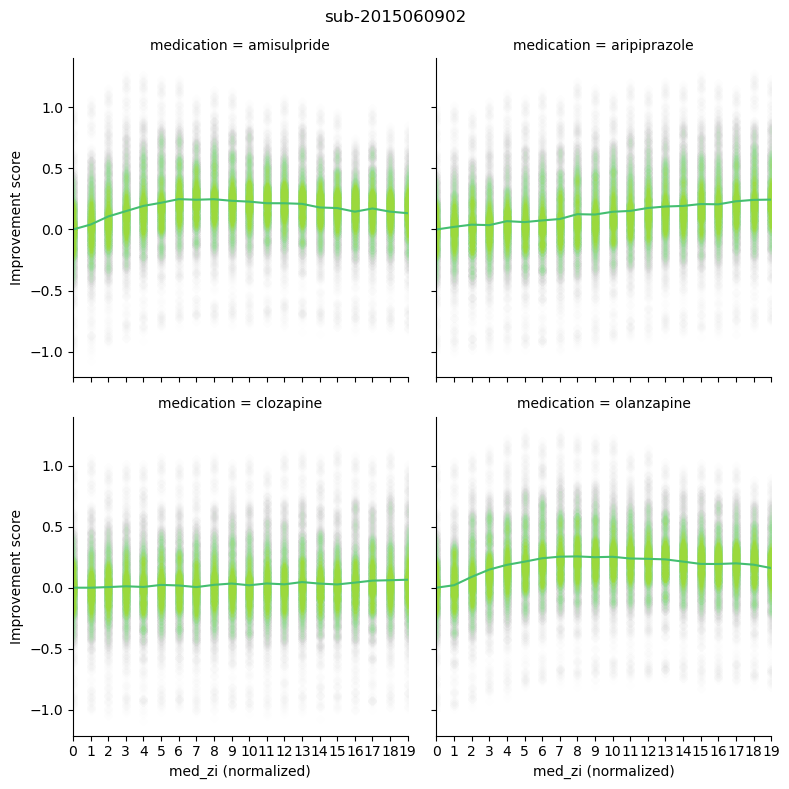

In [ ]:
result_df['med_zi_norm'] = result_df.groupby('medication')['med_zi'].transform(lambda x: x - x.min())

import seaborn as sns
import matplotlib.pyplot as plt

cmap = sns.color_palette("viridis", as_cmap=True)

point_color = cmap(0.85)  # light green
line_color = cmap(0.7)

g = sns.FacetGrid(
    result_df,
    col="medication",
    col_wrap=2,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x="med_zi_norm",
    y="score",
    alpha=0.005,
    color=point_color
)

g.map_dataframe(
    sns.lineplot,
    x="med_zi_norm",
    y="score",
    estimator="mean",
    ci=None,
    color=line_color
)

for ax in g.axes.flatten():
    ax.set_xlim(0, 19)
    ax.set_xticks(range(20))

g.set_axis_labels("med_zi (normalized)", "Improvement score")

plt.suptitle(pid)
plt.tight_layout()
plt.savefig(f'{med_results_dir}/{Paths.TYPE_OF_SWEEP}_medication_diff.png')
plt.show()

In [ ]:
base_med_zi = med_results_specific_med['med_zi'].min()
base_feat = med_results_specific_med[med_results_specific_med['med_zi']==base_med_zi][feat]
score_i = []
med_zi_i = []

for i in med_results_specific_med.index:
    for j in base_feat.index:
        score_i.append(np.sum(med_results_specific_med.loc[i, feat] > base_feat.loc[j, feat]))
        med_zi_i.append(med_results_specific_med.loc[i, 'med_zi'])



In [117]:
score_df = pd.DataFrame({'score': score_i, 'medication': [medication]*len(score_i), 'med_zi': med_zi_i})

/tmp/ipykernel_3880462/279580412.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


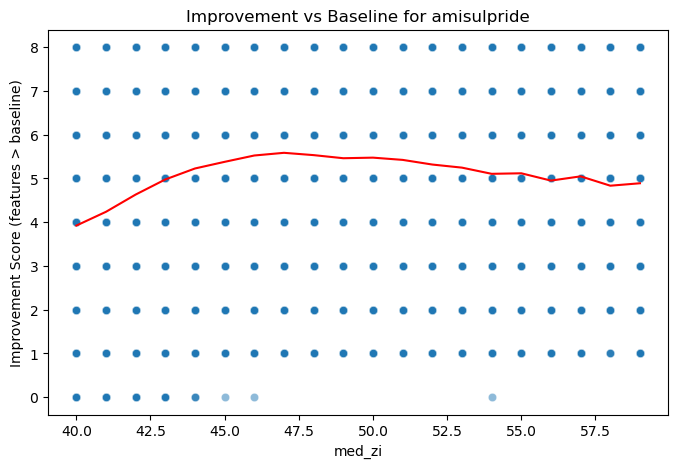

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# scatter plot
sns.scatterplot(data=score_df, x='med_zi', y='score', alpha=0.5)

# smooth interpolation / trend line
sns.lineplot(
    data=score_df, 
    x='med_zi', 
    y='score', 
    ci=None,  # no confidence interval
    estimator='mean',  # average score per med_zi
    color='red'
)

plt.xlabel('med_zi')
plt.ylabel('Improvement Score (features > baseline)')
plt.title(f'Improvement vs Baseline for {medication}')
plt.show()

In [99]:
baseline_zi = med_results_specific_med['med_zi'].min()
baseline_df = med_results_specific_med[
    med_results_specific_med['med_zi'] == baseline_zi
]

scores = []

for zi in med_results_specific_med['med_zi'].unique():
    group = med_results_specific_med[
        med_results_specific_med['med_zi'] == zi
    ]

    score_zi = 0

    for f in feat:
        # all pairwise comparisons (20 x 20)
        comparisons = group[f].values[:, None] > baseline_df[f].values

        # probability that group > baseline
        prob = comparisons.mean()

        score_zi += prob

    scores.append((zi, score_zi))

score_df = pd.DataFrame(scores, columns=['med_zi', 'score'])
score_df['medication'] = medication

In [100]:
score_df

,med_zi,score,medication
0,60,3.9200,olanzapine
1,61,3.6248,olanzapine
2,62,3.5932,olanzapine
3,63,3.4268,olanzapine
4,64,3.4424,olanzapine
5,65,3.4328,olanzapine
6,66,3.4972,olanzapine
7,67,3.6468,olanzapine
8,68,4.1300,olanzapine
9,69,4.3940,olanzapine


In [101]:
for i in base_feat.index:
    for j in base_feat.index:
        score_i.append(np.sum(base_feat.loc[i, feat] > base_feat.loc[j, feat]))
        #med_zi_i.append(base_feat.loc[i, 'med_zi'])
    

In [102]:
base_feat

,L.PU-L.CACG,L.PU-L.RACG,R.PU-R.CACG,R.PU-R.RACG,L.PU-L.IN,R.PU-R.IN,L.CA-L.HI,R.CA-R.HI
0,0.226048,0.235842,0.204073,0.212280,0.482069,0.537229,0.290759,0.343443
1,0.219303,0.240526,0.233995,0.241088,0.515068,0.602902,0.298073,0.327994
2,0.261838,0.335649,0.184326,0.190290,0.448046,0.562537,0.291570,0.357057
3,0.146751,0.214303,0.208117,0.209023,0.490443,0.501694,0.334230,0.308556
4,0.296508,0.291207,0.191180,0.181637,0.461680,0.581188,0.271825,0.343289
5,0.290935,0.201411,0.239748,0.297309,0.483382,0.515229,0.213756,0.302763
6,0.259900,0.250415,0.191871,0.180997,0.523284,0.550480,0.305364,0.375307
7,0.293460,0.263440,0.229869,0.256743,0.480654,0.610020,0.337396,0.376937
8,0.260885,0.260177,0.192373,0.161433,0.505451,0.569017,0.244357,0.354860
9,0.188423,0.284606,0.150620,0.220188,0.533184,0.512180,0.320110,0.314773
